In [1]:
import pandas as pd



## Transformacion

In [2]:
icaeh_2022=pd.read_csv("ICAE_municipal/ICAEH_2022.csv")
icaeh_2023=pd.read_csv("ICAE_municipal/ICAEH_2023_50.csv")
icaeh_2024=pd.read_csv("ICAE_municipal/ICAEH_2024_50.csv")




In [8]:
def flatten_iae(df):
    df['IAE'] = df['IAE'].str.replace('%', '', regex=False).astype(float) / 100


flatten_iae(icaeh_2022)
flatten_iae(icaeh_2023)
flatten_iae(icaeh_2024)



In [3]:
icaeh_2022['COBERTURA'] =(pd.to_numeric(icaeh_2022['COBERTURA'].str.replace(',', '', regex=False), errors='coerce')
                        .fillna(0))

In [5]:
# Solo si estás SEGURO de que todos tienen 5 columnas
new_column_names = ["DEPARTAMENTO", "MUNICIPIO", "TOTAL_DE_VIVIENDAS", 
                    "VIVIENDAS_CON_ACCESO_A_ELECTRICIDAD", "IAE"]


icaeh_2024[['Departamentos', 'Municipios']] = icaeh_2024[['Municipios', 'Departamentos']].values


icaeh_2022 = icaeh_2022.drop(columns=['ICE'], errors='ignore')

icaeh_2022.columns = new_column_names
icaeh_2023.columns = new_column_names
icaeh_2024.columns = new_column_names
icaeh_2022["YEAR"]=2022
icaeh_2023["YEAR"]=2023
icaeh_2024["YEAR"]=2024
# Unir
df_completo = pd.concat([icaeh_2022, icaeh_2023, icaeh_2024], ignore_index=True)

In [10]:
df_completo.head(30)

,DEPARTAMENTO,MUNICIPIO,TOTAL_DE_VIVIENDAS,VIVIENDAS_CON_ACCESO_A_ELECTRICIDAD,IAE,YEAR
0,ATLÁNTIDA,La Ceiba,"58,999",57918.0,98.31%,2022
1,ATLÁNTIDA,El Porvenir,"6,894",6657.0,96.92%,2022
2,ATLÁNTIDA,Esparta,"6,580",4574.0,70.47%,2022
3,ATLÁNTIDA,Jutiapa,"9,011",7340.0,84.14%,2022
4,ATLÁNTIDA,La Masica,"12,779",7763.0,62.31%,2022
5,ATLÁNTIDA,San Francisco del Valle,"4,422",3910.0,89.24%,2022
6,ATLÁNTIDA,Tela,"36,646",26958.0,74.28%,2022
7,ATLÁNTIDA,Arizona,"9,002",6590.0,73.52%,2022
8,COLÓN,Trujillo,"16,804",16120.0,96.42%,2022
9,COLÓN,Balfate,"2,275",2253.0,111.30%,2022


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Función para crear gráficas del IAE por municipio y departamento
def visualizar_iae(df):
    """
    Crea gráficas del IAE para 2022, 2023 y 2024
    
    Parámetros:
    df: DataFrame con columnas 'Municipio', 'Departamento', 'IAE', 'Year'
    """
    
    # Verificar que los años sean 2022, 2023, 2024
    años_esperados = [2022, 2023, 2024]
    años_presentes = sorted(df['YEAR'].unique())
    
    print(f"Años presentes en los datos: {años_presentes}")
    
    # 1. GRÁFICO DE BARRAS AGRUPADAS - Comparativa por municipio
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Pivotear los datos para tener años como columnas
df_pivot = df_completo.pivot_table(index=['DEPARTAMENTO', 'MUNICIPIO'], 
                                   columns='YEAR', 
                                   values='IAE',
                                   aggfunc='first')  # o 'mean' si hay múltiples
    # Ordenar por IAE promedio (para mejor visualización)
    pivot_df['promedio'] = pivot_df.mean(axis=1)
    pivot_df = pivot_df.sort_values('promedio', ascending=False).drop('promedio', axis=1)
    
    # Configurar las barras
    x = np.arange(len(pivot_df.index))
    width = 0.25  # Ancho de cada barra
    multiplier = 0
    
    # Colores para cada año
    colores = {2022: '#4CAF50', 2023: '#2196F3', 2024: '#FF9800'}
    etiquetas = {2022: 'IAE 2022', 2023: 'IAE 2023', 2024: 'IAE 2024'}
    
    # Dibujar barras para cada año
    for year in sorted(pivot_df.columns):
        offset = width * multiplier
        if year in pivot_df.columns:
            ax.bar(x + offset, pivot_df[year], width, 
                   label=etiquetas[year], color=colores[year])
        multiplier += 1
    
    # Configurar el gráfico
    ax.set_xlabel('Municipio', fontsize=12)
    ax.set_ylabel('IAE (%)', fontsize=12)
    ax.set_title('Evolución del IAE por Municipio (2022-2024)', fontsize=14, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(pivot_df.index, rotation=45, ha='right')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(0, max(pivot_df.max()) * 1.1)
    
    plt.tight_layout()
    plt.show()
    
    # 2. GRÁFICO DE LÍNEAS - Tendencia por departamento (promedio)
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Calcular promedio por departamento y año
    df_departamento = df.groupby(['DEPARTAMENTO', 'YEAR'])['IAE'].mean().unstack()
    
    for departamento in df_departamento.index:
        años = df_departamento.columns
        valores = df_departamento.loc[departamento]
        ax.plot(años, valores, marker='o', label=departamento, linewidth=2, markersize=8)
    
    ax.set_xlabel('Año', fontsize=12)
    ax.set_ylabel('IAE Promedio (%)', fontsize=12)
    ax.set_title('Evolución del IAE Promedio por Departamento (2022-2024)', fontsize=14, fontweight='bold')
    ax.legend(loc='best', bbox_to_anchor=(1.05, 1))
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xticks([2022, 2023, 2024])
    
    plt.tight_layout()
    plt.show()
    
    # 3. GRÁFICO DE BARRAS APILADAS O AGRUPADAS POR DEPARTAMENTO
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Agrupar por departamento y año, calcular promedio
    df_dep = df.groupby(['DEPARTAMENTO', 'YEAR'])['IAE'].mean().unstack()
    
    # Ordenar por IAE promedio
    df_dep['promedio'] = df_dep.mean(axis=1)
    df_dep = df_dep.sort_values('promedio', ascending=True).drop('promedio', axis=1)
    
    # Gráfico de barras horizontales
    y = np.arange(len(df_dep.index))
    width = 0.25
    multiplier = 0
    
    for year in sorted(df_dep.columns):
        offset = width * multiplier
        ax.barh(y + offset, df_dep[year], width, 
                label=etiquetas[year], color=colores[year])
        multiplier += 1
    
    ax.set_xlabel('IAE Promedio (%)', fontsize=12)
    ax.set_ylabel('Departamento', fontsize=12)
    ax.set_title('IAE Promedio por Departamento (2022-2024)', fontsize=14, fontweight='bold')
    ax.set_yticks(y + width)
    ax.set_yticklabels(df_dep.index)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, linestyle='--', axis='x')
    
    plt.tight_layout()
    plt.show()
    
    # 4. HEATMAP O TABLA DE RESULTADOS
    fig, ax = plt.subplots(figsize=(10, len(df_dep) * 0.5 + 2))
    ax.axis('tight')
    ax.axis('off')
    
    # Preparar datos para la tabla
    tabla_dep = df_dep.reset_index()
    tabla_dep.columns = ['DEPARTAMENTO', 'IAE 2022', 'IAE 2023', 'IAE 2024']
    
    # Crear tabla
    table = ax.table(cellText=tabla_dep.values,
                     colLabels=tabla_dep.columns,
                     cellLoc='center',
                     loc='center',
                     colColours=['#4472C4']*4)
    
    # Formatear tabla
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    # Colorear celdas según valor
    for (i, j), cell in table.get_celld().items():
        if i == 0:  # Encabezados
            cell.set_text_props(color='white', fontweight='bold')
        elif j > 0:  # Celdas de datos (no la columna de departamento)
            valor = float(tabla_dep.iloc[i-1, j])
            if valor >= 80:
                cell.set_facecolor('#C6EFCE')  # Verde
            elif valor >= 60:
                cell.set_facecolor('#FFEB9C')  # Amarillo
            else:
                cell.set_facecolor('#FFC7CE')  # Rojo
    
    plt.title('Resumen IAE por Departamento (2022-2024)', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # 5. ESTADÍSTICAS DESCRIPTIVAS
    print("\n" + "="*60)
    print("ESTADÍSTICAS DESCRIPTIVAS DEL IAE")
    print("="*60)
    
    for year in [2022, 2023, 2024]:
        data_year = df[df['Year'] == year]['IAE']
        print(f"\n--- IAE {year} ---")
        print(f"  Promedio: {data_year.mean():.2f}%")
        print(f"  Mediana:  {data_year.median():.2f}%")
        print(f"  Mínimo:   {data_year.min():.2f}%")
        print(f"  Máximo:   {data_year.max():.2f}%")
        print(f"  Desv. Std:{data_year.std():.2f}%")
    
    # 6. MUNICIPIO CON MEJOR Y PEOR IAE por año
    print("\n" + "="*60)
    print("MUNICIPIOS DESTACADOS")
    print("="*60)
    
    for year in [2022, 2023, 2024]:
        df_year = df[df['YEAR'] == year]
        mejor = df_year.loc[df_year['IAE'].idxmax()]
        peor = df_year.loc[df_year['IAE'].idxmin()]
        
        print(f"\n--- {year} ---")
        print(f"  🏆 Mejor: {mejor['Municipio']} ({mejor['Departamento']}) - {mejor['IAE']:.2f}%")
        print(f"  📉 Peor:  {peor['Municipio']} ({peor['Departamento']}) - {peor['IAE']:.2f}%")



SyntaxError: invalid syntax. Perhaps you forgot a comma? (3168965263.py, line 24)

Años presentes en los datos: [np.int64(2022), np.int64(2023), np.int64(2024)]


ValueError: Index contains duplicate entries, cannot reshape

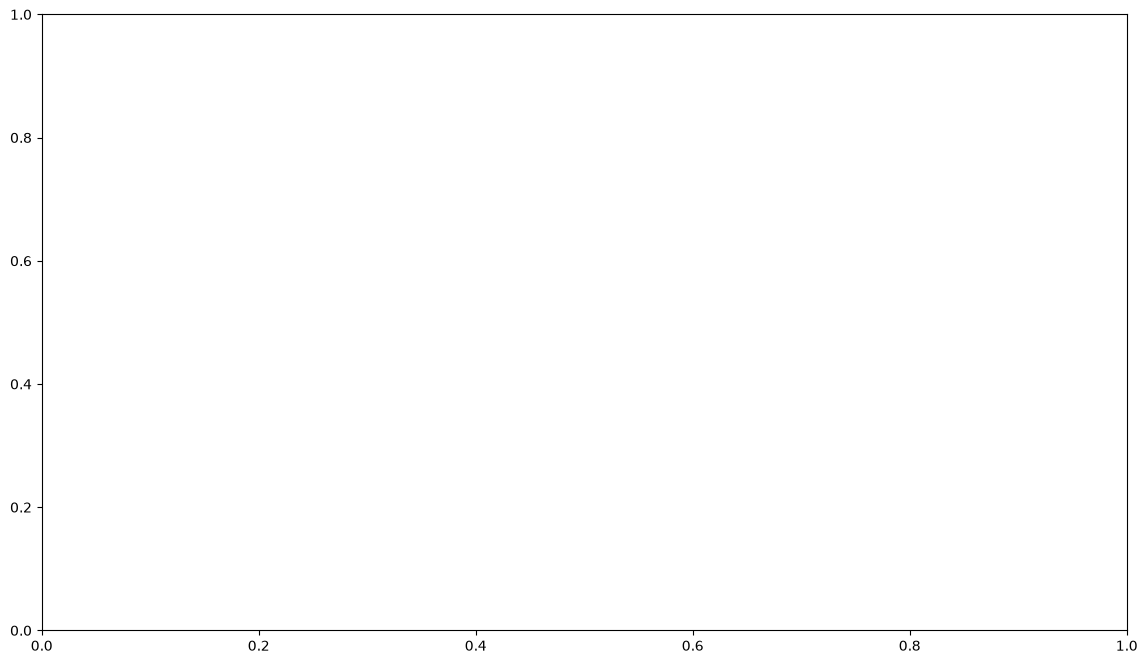

In [12]:
visualizar_iae(df_completo)